# Visualize one MRI across stages: raw → preprocessed → slices

Set `IMAGE_DATA_ID` (cell 3) and inspect a single scan:

1. **Raw** 3D volume (as downloaded — DICOM series or `.nii`), three orientations.
2. **Preprocessed** 3D volume (registered + cropped to 100³), three orientations.
3. **Already-created 2D slices** for that image (the `.npz` files under `processed/storage/`).

Structure: **cell 1** = imports, **cell 2** = all config + functions, **cell 3** = pick the image.

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the repo root so the relative data/ paths resolve.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if os.path.basename(os.getcwd()) == '2026_paper':
    os.chdir(REPO_ROOT)
print('Working dir:', os.getcwd())

# Shared MRI loader (handles DICOM series / .nii.gz / .npz).
sys.path.append(os.path.join(REPO_ROOT, 'src'))
sys.path.append(os.path.join(REPO_ROOT, 'src', 'utils'))
from base_mri import load_mri  # noqa: E402

Working dir: /home/lucasthim/projects/phd/mmml-alzheimer-diagnosis


In [2]:
# ===== Config: data roots & reference tables =====
RAW_REFERENCE     = 'data/reference/DOWNLOAD_RAW_MRI.csv'                                    # image_data_id -> raw scan
PREPROCESSED_ROOT = '/mnt/d/lucas/Downloads/preprocessed'                                   # dated 3D .nii.gz run folders
PROCESSED_ROOT    = 'data/mri/processed/storage'                                            # 2D .npz slices, per image
LABEL_REFERENCE   = 'data/reference/PROCESSED_MRI_REFERENCE_ALL_ORIENTATIONS_20260710_1413.csv'

RAW_REF   = pd.read_csv(RAW_REFERENCE)
LABEL_REF = pd.read_csv(LABEL_REFERENCE) if os.path.exists(LABEL_REFERENCE) else None


# ===== Path building =====
def get_label(image_data_id):
    """Diagnosis (MACRO_GROUP) for an image id, from the processed MRI reference; None if unknown."""
    if LABEL_REF is None:
        return None
    hit = LABEL_REF.loc[LABEL_REF['IMAGE_DATA_ID'] == image_data_id, 'MACRO_GROUP']
    return hit.iloc[0] if len(hit) else None


def build_paths(image_data_id):
    """Resolve raw / preprocessed / processed locations for an ADNI image id (e.g. 'I94615').

    raw          : from DOWNLOAD_RAW_MRI.csv -> `.nii`: PATH/IMAGE_NAME | DICOM: the I<id> folder.
    preprocessed : globbed as <root>/*/ADNI_<subject>_<id>.nii.gz across the dated run folders.
    processed    : the per-image storage folder holding the 2D .npz slices.
    """
    hits = RAW_REF[RAW_REF['IMAGE_DATA_ID'] == image_data_id]
    if hits.empty:
        raise ValueError(f'{image_data_id!r} not found in {RAW_REFERENCE}')
    row = hits.iloc[0]
    subject, fmt = row['SUBJECT'], str(row['FORMAT']).lower()
    raw_path = row['PATH'] if fmt == 'dcm' else os.path.join(row['PATH'], row['IMAGE_NAME'])
    prep = sorted(glob.glob(os.path.join(PREPROCESSED_ROOT, '*', f'ADNI_{subject}_{image_data_id}.nii.gz')))
    return {
        'image_data_id': image_data_id,
        'subject': subject,
        'format': fmt,
        'label': get_label(image_data_id),
        'raw_path': raw_path,
        'preprocessed_path': prep[0] if prep else None,
        'processed_dir': os.path.join(PROCESSED_ROOT, image_data_id),
    }


# ===== Array helpers =====
def to_numpy(img):
    """ANTsImage or ndarray -> ndarray."""
    return img.numpy() if hasattr(img, 'numpy') else np.asarray(img)


# def slice_2d(vol, orientation, index):
#     """2D slice using the pipeline's orientation convention (matches mri_augmentation.slice_image)."""
#     vol = to_numpy(vol)
#     if orientation == 'axial':
#         return np.rot90(vol, k=3, axes=(0, 1))[:, :, index]
#     if orientation == 'coronal':
#         return np.rot90(vol, k=3, axes=(0, 2))[:, index, :]
#     if orientation == 'sagittal':
#         rot = np.rot90(vol, k=3, axes=(1, 2))
#         return np.rot90(rot, k=2, axes=(0, 2))[index, :, :]
#     raise ValueError(f'unknown orientation: {orientation!r}')

def slice_2d(image_3d,orientation,orientation_slice):
    
    '''
    
    Slice a 3D image and create a 2D image.
    
    Since ANTsImage to Numpy convertion makes the image lose the reference, we rotate it some times to the correct the axis visualization.
    
    Axis orientation:
    0 - Sagittal
    1 - Coronal
    2 - Axial
    
    Parameters
    ----------
    
    
    image_3d: 3D MRI object in memory
    
    orientation: Orientation to cut the image. Values can be "coronal", "sagittal" or "axial"
    
    orientation_slice: Point to slice the 3D image. Values range from 0 to 100. TODO: fix future bug if sampling_range is outside of the image
    Returns
    ----------
    Returns a 2D image.
    
    '''
    image_3d = to_numpy(image_3d)
    if orientation == 'sagittal':
        rot = np.rot90(image_3d, k=3, axes=(1,2)).copy()
        rot = np.rot90(rot, k=2, axes=(0,2)).copy()
        return rot[orientation_slice,:,:]
    
    elif orientation == 'coronal':
        rot = np.rot90(image_3d, k=3, axes=(0,2)).copy()
        return rot[:,orientation_slice,:]
    
    elif orientation == 'axial':
        rot = np.rot90(image_3d, k=3, axes=(0,1)).copy()        
        return rot[:,:,orientation_slice]

# ===== Visualization =====
def show_orthogonal(vol, title='', slices=None):
    """Show axial / coronal / sagittal slices of a 3D volume.

    slices: optional dict {orientation: index}; any omitted orientation uses the mid-slice.
            e.g. slices={'axial': 8} to inspect the exact slice the pipeline cut.
    """
    vol = to_numpy(vol)
    # mids = {'axial': vol.shape[2] // 2, 'coronal': vol.shape[1] // 2, 'sagittal': vol.shape[0] // 2}
    mids = {'axial': vol.shape[2] // 2, 'coronal': vol.shape[1] // 2, 'sagittal': vol.shape[0] // 2}
    idx = {**mids, **(slices or {})}
    print(f'{title}  shape={vol.shape}  min={vol.min():.3f}  max={vol.max():.3f}  '
          f'mean={vol.mean():.3f}  nonzero={np.count_nonzero(vol)}')
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ax, orient in zip(axes, ['axial', 'coronal', 'sagittal']):
        s = slice_2d(vol, orient, idx[orient])
        ax.imshow(s, cmap='gray')
        ax.set_title(f'{orient} @ {idx[orient]}   ({int((s > 0).sum())} nz px)')
        ax.axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def show_volume_from_path(path, title='', slices=None):
    """Load a 3D volume (raw DICOM/.nii or preprocessed .nii.gz) and show its three orientations."""
    if path is None or not os.path.exists(path):
        print(f'[missing volume] {path}')
        return
    show_orthogonal(load_mri(path=path, as_ants=True), title=title, slices=slices)


def show_created_slices(processed_dir, title=''):
    """Display every already-created 2D .npz slice in an image's processed storage folder."""
    paths = sorted(glob.glob(os.path.join(processed_dir, '*.npz')))
    if not paths:
        print(f'No .npz slices found in {processed_dir}')
        return
    ncols = min(len(paths), 3)
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, p in zip(axes, paths):
        arr = np.load(p)['arr_0']
        ax.imshow(arr, cmap='gray')
        ax.set_title(f"{os.path.basename(p).replace('.npz', '')}   ({int((arr > 0).sum())} nz px)", fontsize=10)
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')
    fig.suptitle(title or f'Created slices — {os.path.basename(processed_dir)} ({len(paths)} files)', fontsize=13)
    plt.tight_layout()
    plt.show()

In [3]:
IMAGE_DATA_ID = 'I94615'   # <- any id in DOWNLOAD_RAW_MRI.csv. e.g. I1553005 = DICOM CN. (I94615's axial_08 is empty.)

paths = build_paths(IMAGE_DATA_ID)

# Optional manual overrides (uncomment to point at specific files instead of the auto-resolved ones):
# paths['preprocessed_path'] = '/mnt/d/lucas/Downloads/preprocessed/20260709/ADNI_..._I....nii.gz'
# paths['processed_dir']     = 'data/mri/processed/storage/I....'

for k, v in paths.items():
    extra = ''
    if k == 'raw_path':          extra = f"   (exists: {os.path.exists(v)})"
    if k == 'preprocessed_path': extra = f"   (exists: {v is not None and os.path.exists(v)})"
    if k == 'processed_dir':     extra = f"   (n slices: {len(glob.glob(os.path.join(v, '*.npz')))})"
    print(f'{k:20}: {v}{extra}')

image_data_id       : I94615
subject             : 114_S_0173
format              : nii
label               : CN
raw_path            : /mnt/d/lucas/Downloads/raw/ADNI/114_S_0173/MPR__GradWarp__B1_Correction__N3__Scaled/2008-02-14_17_32_54.0/I94615/ADNI_114_S_0173_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080229182339139_S45745_I94615.nii   (exists: True)
preprocessed_path   : /mnt/d/lucas/Downloads/preprocessed/20260707/ADNI_114_S_0173_I94615.nii.gz   (exists: True)
processed_dir       : data/mri/processed/storage/I94615   (n slices: 5)


## 1 — Raw 3D volume (axial / coronal / sagittal)

Native resolution, no registration or skull-stripping.

RAW — I94615 (114_S_0173, CN)  shape=(192, 192, 160)  min=0.000  max=2218.729  mean=173.616  nonzero=3813222


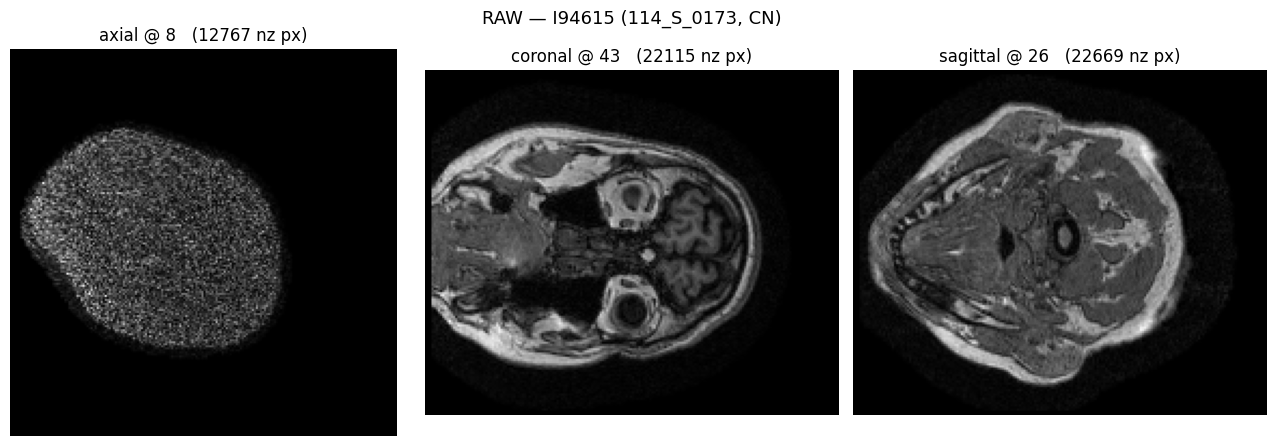

In [4]:
show_volume_from_path(paths['raw_path'],
                      title=f"RAW — {IMAGE_DATA_ID} ({paths['subject']}, {paths['label']})",
                      slices={'axial': 8, 'coronal': 43, 'sagittal': 26})

In [5]:
path = paths['raw_path']
title=f"RAW — {IMAGE_DATA_ID} ({paths['subject']}, {paths['label']})"
mri = load_mri(path=path, as_ants=True)

In [6]:
path

'/mnt/d/lucas/Downloads/raw/ADNI/114_S_0173/MPR__GradWarp__B1_Correction__N3__Scaled/2008-02-14_17_32_54.0/I94615/ADNI_114_S_0173_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080229182339139_S45745_I94615.nii'

In [7]:
mri

ANTsImage (SAR)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (192, 192, 160)
	 Spacing    : (1.2507, 1.2433, 1.2007)
	 Origin     : (-90.6771, -141.5904, 108.5301)
	 Direction  : [-0. -0.  1. -0.  1.  0. -1. -0.  0.]

In [8]:
# def slice_2d(vol, orientation, index):
#     """2D slice using the pipeline's orientation convention (matches mri_augmentation.slice_image)."""
#     vol = to_numpy(vol)
#     if orientation == 'sagittal':
#         return np.rot90(vol, k=3, axes=(0, 1))[:, :, index]
#     if orientation == 'coronal':
#         return np.rot90(vol, k=3, axes=(0, 2))[:, index, :]
#     if orientation == 'axial':
#         rot = np.rot90(vol, k=3, axes=(1, 2))
#         return np.rot90(rot, k=2, axes=(0, 2))[index, :, :]
#     raise ValueError(f'unknown orientation: {orientation!r}')

# # ===== Visualization =====
# def show_orthogonal(vol, title='', slices=None):
#     """Show axial / coronal / sagittal slices of a 3D volume.

#     slices: optional dict {orientation: index}; any omitted orientation uses the mid-slice.
#             e.g. slices={'axial': 8} to inspect the exact slice the pipeline cut.
#     """
#     vol = to_numpy(vol)
#     # mids = {'axial': vol.shape[2] // 2, 'coronal': vol.shape[1] // 2, 'sagittal': vol.shape[0] // 2}
#     mids = {'axial': vol.shape[2] // 2, 'coronal': vol.shape[1] // 2, 'sagittal': vol.shape[0] // 2}
#     idx = {**mids, **(slices or {})}
#     print(f'{title}  shape={vol.shape}  min={vol.min():.3f}  max={vol.max():.3f}  '
#           f'mean={vol.mean():.3f}  nonzero={np.count_nonzero(vol)}')
#     fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
#     for ax, orient in zip(axes, ['axial', 'coronal', 'sagittal']):
#         s = slice_2d(vol, orient, idx[orient])
#         ax.imshow(s, cmap='gray')
#         ax.set_title(f'{orient} @ {idx[orient]}   ({int((s > 0).sum())} nz px)')
#         ax.axis('off')
#     fig.suptitle(title, fontsize=13)
#     plt.tight_layout()
#     plt.show()
    
# slices={'axial': 92, 'coronal': 90, 'sagittal': 100}
# show_orthogonal(mri,title)
# # THIS IS THE RAW IMAGE, I GOTTA CHECK THE PREPROCESSED ONE, BECAUSE THE AXIAL_08 IS EMPTY. I THINK IT'S A DICOM ISSUE.

In [9]:
# ===== Interactive: rot90(k, axes) explorer =====
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display

def rot90_slice(vol, k, axis_a, axis_b, remaining, index):
    """np.rot90(vol, k, axes=(axis_a, axis_b)), then index into the remaining axis.

    axis_a == axis_b has no rotation plane, so it falls back to an unrotated slice.
    """
    rotated = vol if axis_a == axis_b else np.rot90(vol, k=k, axes=(axis_a, axis_b))
    idx = [slice(None)] * 3
    idx[remaining] = index
    return rotated[tuple(idx)]


def explore_rotations(vol, title=''):
    """Interactive rot90(k, axes) explorer for a 3D volume (ANTsImage or ndarray).

    Sliders/dropdowns for k, axis a, axis b, and the slice index into the remaining axis.
    Call once per volume to compare several images side by side.
    """
    vol_np = to_numpy(vol)
    axis_options = [(f'{i} (size {vol_np.shape[i]})', i) for i in range(3)]

    k_w      = widgets.IntSlider(value=3, min=0, max=3, step=1, description='k:')
    axis_a_w = widgets.Dropdown(options=axis_options, value=1, description='axis a:')
    axis_b_w = widgets.Dropdown(options=axis_options, value=2, description='axis b:')
    start_remaining = ({0, 1, 2} - {axis_a_w.value, axis_b_w.value}).pop()
    index_w  = widgets.IntSlider(value=vol_np.shape[start_remaining] // 2,
                                  min=0, max=vol_np.shape[start_remaining] - 1, description='index:')
    info_w   = widgets.HTML()

    fig = go.FigureWidget(data=[go.Heatmap(z=np.zeros((2, 2)), colorscale='gray')])
    fig.update_yaxes(autorange='reversed', scaleanchor='x')
    fig.update_layout(width=520, height=520, margin=dict(l=40, r=40, t=50, b=40))

    def update(*_):
        a, b = axis_a_w.value, axis_b_w.value
        same_axis = a == b
        if same_axis and k_w.value != 0:
            k_w.value = 0   # k has no meaning without a rotation plane; the reentrant call finishes the update
            return
        remaining = a if same_axis else ({0, 1, 2} - {a, b}).pop()
        index_w.max = vol_np.shape[remaining] - 1
        index = min(index_w.value, index_w.max)
        s = rot90_slice(vol_np, k_w.value, a, b, remaining, index)
        with fig.batch_update():
            fig.data[0].z = s
            note = '  (axis a == axis b: no rotation, k ignored)' if same_axis else ''
            prefix = f'{title}  ' if title else ''
            fig.layout.title = f'{prefix}k={k_w.value}  axes=({a},{b})  remaining_axis={remaining}  index={index}{note}'
        info_w.value = f'shape={s.shape}   nonzero={int((s > 0).sum())} / {s.size}'

    for w in (k_w, axis_a_w, axis_b_w, index_w):
        w.observe(update, names='value')

    update()
    display(widgets.VBox([widgets.HBox([k_w, axis_a_w, axis_b_w]), index_w, info_w, fig]))

In [ ]:
path = paths['raw_path']
title=f"RAW — {IMAGE_DATA_ID} ({paths['subject']}, {paths['label']})"
mri = load_mri(path=path, as_ants=True)
explore_rotations(mri, title=f'RAW — {IMAGE_DATA_ID}')

# To compare another image, load it and call again — e.g.:
# other_mri = load_mri(path=build_paths('I1553005')['raw_path'], as_ants=True)
# explore_rotations(other_mri, title='RAW — I1553005')

In [ ]:
mri

ANTsImage (SAR)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (192, 192, 160)
	 Spacing    : (1.2507, 1.2433, 1.2007)
	 Origin     : (-90.6771, -141.5904, 108.5301)
	 Direction  : [-0. -0.  1. -0.  1.  0. -1. -0.  0.]

## 2 — Preprocessed 3D volume (100³)

Registered to the atlas and center-cropped to 100×100×100. Pass `slices=` to inspect the exact
indices the pipeline cuts — e.g. `slices={'axial': 8, 'coronal': 43, 'sagittal': 26}` — to see why a
given slice came out empty.

PREPROCESSED @ trained slices — I94615  shape=(100, 100, 100)  min=0.000  max=8.780  mean=1.629  nonzero=421098


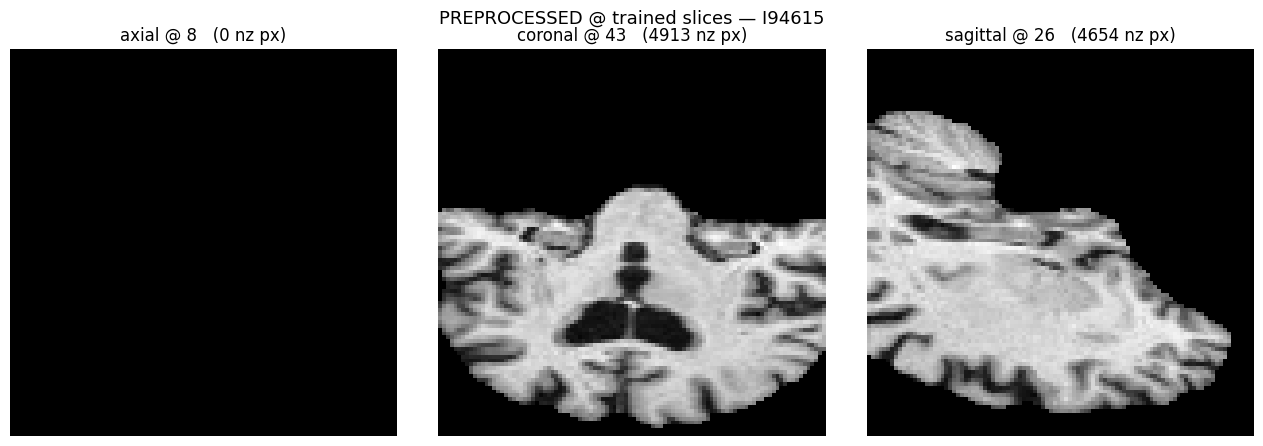

In [10]:
# show_volume_from_path(paths['preprocessed_path'],
#                       title=f"PREPROCESSED — {IMAGE_DATA_ID} ({paths['subject']}, {paths['label']})")

# Inspect the exact trained slice indices (uncomment):
show_volume_from_path(paths['preprocessed_path'],
                      title=f"PREPROCESSED @ trained slices — {IMAGE_DATA_ID}",
                      slices={'axial': 8, 'coronal': 43, 'sagittal': 26})

In [ ]:
preprocessed_mri = load_mri(path=paths['preprocessed_path'], as_ants=True)
preprocessed_mri

ANTsImage (RPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (100, 100, 100)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (41.0, -59.0, 41.0)
	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [13]:
explore_rotations(preprocessed_mri, title=f'RAW — {IMAGE_DATA_ID}')

## 3 — Already-created 2D slices

The `.npz` slices produced for this image, under `processed/storage/<image_data_id>/`. A missing
orientation/slice (e.g. `axial_08`) means that slice came out empty and was not saved.

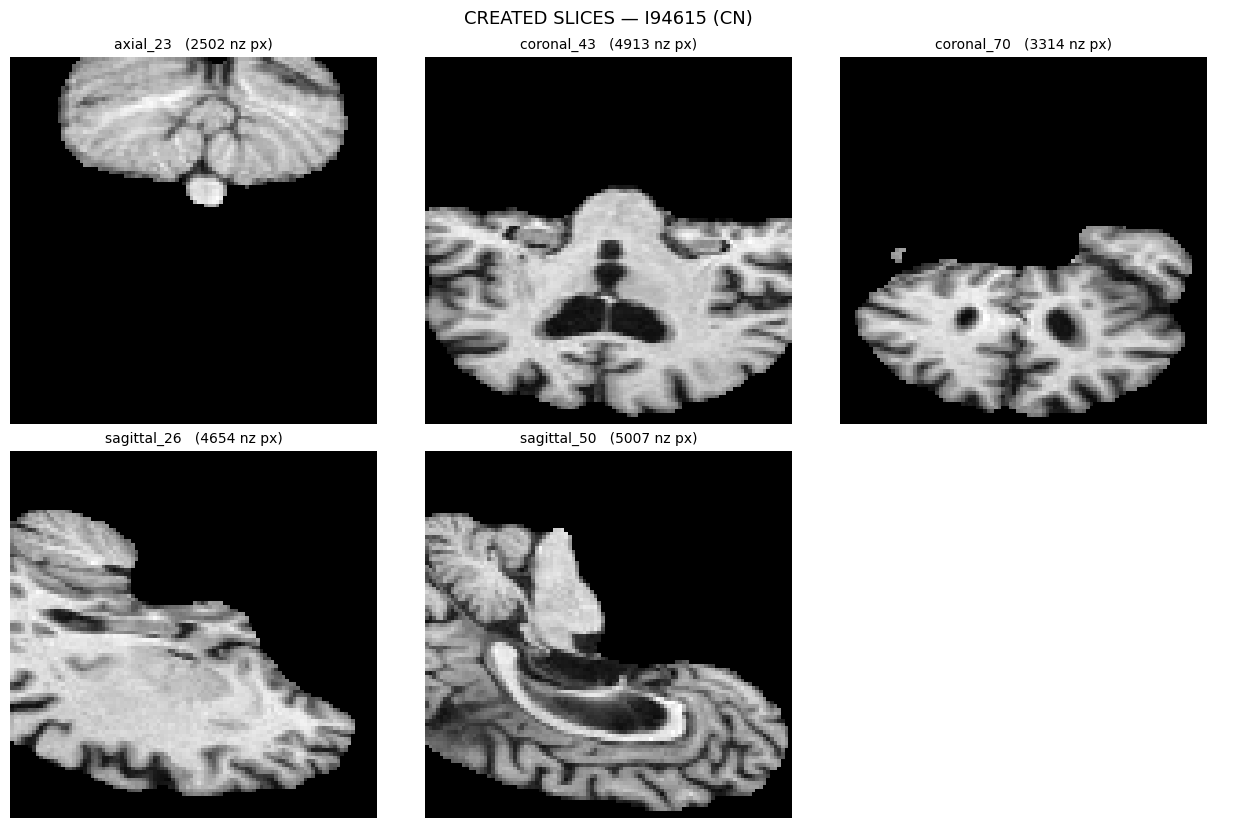

In [6]:
show_created_slices(paths['processed_dir'],
                    title=f"CREATED SLICES — {IMAGE_DATA_ID} ({paths['label']})")